# **Workshop: Data Analysis with BigQuery and Gemini**


### Overview

This notebook provides a comprehensive walkthrough of a data analysis and machine learning project focused on customer segmentation. It demonstrates how to leverage Google Cloud's powerful tools—BigQuery for large-scale data processing, BigQuery ML (via BigFrames) for clustering, and the Gemini Pro model for creative content generation—to derive actionable business insights from raw e-commerce data.

The primary goal is to segment customers based on their purchasing behavior (Recency, Frequency, Monetary Value) and then use these segments to create targeted marketing campaigns.

### Technologies & Libraries Used

*   **Google Cloud:**
    *   Vertex AI
    *   BigQuery
    *   Colab Enterprise
*   **Python Libraries:**
    *   `google-cloud-bigquery`
    *   `google-cloud-aiplatform`
    *   `bigframes` (for interacting with BigQuery data using a pandas-like API)
    *   `pandas`
    *   `matplotlib` (for data visualization)
    *   `vertexai` (for using the Gemini model)

### Workflow

1.  **Data Preparation in BigQuery:**
    *   A SQL query is executed to process the `bigquery-public-data.thelook_ecommerce.order_items` public dataset.
    *   A new table, `ecommerce.customer_stats`, is created. This table aggregates customer data to calculate RFM (Recency, Frequency, Monetary) metrics: `days_since_last_order`, `count_orders`, and `average_spend`.

2.  **Data Exploration with BigFrames:**
    *   The `customer_stats` table from BigQuery is loaded into a BigQuery DataFrame (`bqdf`).
    *   Standard exploratory data analysis is performed using familiar pandas methods like `.head()`, `.info()`, and `.describe()` to understand the data's structure and statistics.

3.  **Customer Segmentation with K-Means:**
    *   The data is split into training and test sets.
    *   A K-Means clustering model with 5 clusters is created and trained on the RFM features using `bigframes.ml.cluster.KMeans`.
    *   The trained model is saved directly back into BigQuery for persistence and future use.
    *   Predictions are made on the test data to assign each customer to a specific cluster.

4.  **Visualization and Analysis:**
    *   The clusters are visualized using a `matplotlib` scatter plot to show the relationship between `days_since_last_order` and `average_spend`, colored by cluster.
    *   The centroids of the K-Means model are queried from BigQuery using `ML.CENTROIDS` to analyze the defining characteristics of each customer segment.

5.  **Generative AI for Marketing Strategy:**
    *   The Vertex AI SDK is initialized to use the Gemini Pro model.
    *   A detailed prompt is engineered, providing the model with the summarized data for each cluster.
    *   The model is asked to act as a creative brand strategist and generate a unique persona, a catchy campaign title, and a step-by-step marketing action plan for each of the 5 customer segments.

In [1]:
!pip install rich

In [2]:
from rich.console import Console
console = Console()

## **Define variables and initialize BigQuery and VertexAI**

In [3]:
from google.cloud import bigquery
from google.cloud import aiplatform
import bigframes.pandas as bpd
import pandas as pd
from bigframes.ml.cluster import KMeans
from bigframes.ml.model_selection import train_test_split

In [4]:
project_id = 'devhack-3f0c2'
dataset_name = "ecommerce"
model_name = "customer_segmentation_model"
table_name = "customer_stats"
location = "us-central1"
client = bigquery.Client(project=project_id)

## **Create customer statistics table and import from public dataset**

RFM customer segmentation is a marketing technique that categorizes customers based on their purchase behavior. It uses three key metrics: Recency (R), Frequency (F), and Monetary Value (M) to understand customer value and predict future behavior. By analyzing these metrics, businesses can create targeted marketing campaigns and improve customer retention.

In [11]:
%%bigquery
CREATE OR REPLACE TABLE ecommerce.customer_stats AS
SELECT
  user_id,
  DATE_DIFF(CURRENT_DATE(), CAST(MAX(order_created_date) AS DATE), day) AS days_since_last_order, ---RECENCY
  COUNT(order_id) AS count_orders, --FREQUENCY
  AVG(sale_price) AS average_spend --MONETARY
  FROM (
      SELECT
        user_id,
        order_id,
        sale_price,
        created_at AS order_created_date
        FROM `bigquery-public-data.thelook_ecommerce.order_items`
        WHERE
        created_at
            BETWEEN '2020-01-01' AND '2025-07-01'
  )
GROUP BY user_id;

Query is running:   0%|          |

""


## **Create BigFrame**

BigQuery DataFrames is a set of open source Python libraries that let you take advantage of BigQuery data processing by using familiar Python APIs. BigQuery DataFrames provides a Pythonic DataFrame powered by the BigQuery engine, and it implements the pandas and scikit-learn APIs by pushing the processing down to BigQuery through SQL conversion. This lets you use BigQuery to explore and process terabytes of data, and also train machine learning (ML) models, all with Python APIs.

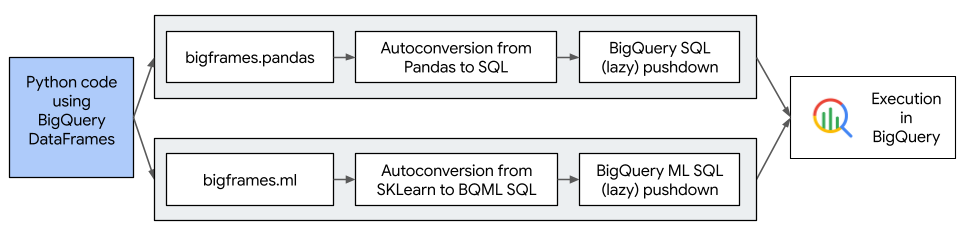

In [12]:
bqdf = bpd.read_gbq(f"{project_id}.{dataset_name}.{table_name}")

/usr/local/lib/python3.10/dist-packages/bigframes/core/log_adapter.py:175: UserWarning: Reading cached table from 2025-08-02 05:39:45.934486+00:00 to avoid
incompatibilies with previous reads of this table. To read the latest
version, set `use_cache=False` or close the current session with
Session.close() or bigframes.pandas.close_session().
  return method(*args, **kwargs)


,user_id,days_since_last_order,count_orders,average_spend
66824,39659,292,2,29.75
66825,89088,353,1,122.599998
66826,14968,90,3,68.353334
66827,67420,573,1,60.0
66828,24635,328,1,36.0


In [13]:
bqdf.head()

,user_id,days_since_last_order,count_orders,average_spend
0,78893,470,1,25.0
1,14936,926,2,19.99
2,46129,696,5,30.700001
3,30947,237,1,22.01
4,56791,50,2,25.770001


In [14]:
bqdf.info()

<class 'bigframes.dataframe.DataFrame'>
Index: 66829 entries, 0 to 66828
Data columns (total 4 columns):
  #  Column                 Non-Null Count    Dtype
---  ---------------------  ----------------  -------
  0  user_id                66829 non-null    Int64
  1  days_since_last_order  66829 non-null    Int64
  2  count_orders           66829 non-null    Int64
  3  average_spend          66829 non-null    Float64
dtypes: Float64(1), Int64(3)
memory usage: 2673160 bytes


In [15]:
bqdf.describe()

,user_id,days_since_last_order,count_orders,average_spend
count,66829.0,66829.0,66829.0,66829.0
mean,49974.20943,433.598168,2.135824,59.592856
std,28865.96975,340.701708,1.501561,55.328945
min,1.0,33.0,1.0,1.5
25%,24668.0,142.0,1.0,28.995
50%,50112.0,337.0,2.0,45.745
75%,75221.0,658.0,3.0,70.996667
max,100000.0,1309.0,14.0,999.0


In [24]:
bqdf.iloc[:10]

,user_id,days_since_last_order,count_orders,average_spend
0,78893,470,1,25.0
1,14936,926,2,19.99
2,46129,696,5,30.700001
3,30947,237,1,22.01
4,56791,50,2,25.770001
5,21690,34,2,42.475
6,13061,582,2,49.465
7,86132,415,2,124.5
8,6520,437,1,10.08
9,21735,503,2,32.5


In [30]:
bqdf[bqdf["days_since_last_order"] < 50]

,user_id,days_since_last_order,count_orders,average_spend
5,21690,34,2,42.475
24,9435,49,1,40.950001
30,81590,38,5,32.742
60,67749,41,2,32.985
82,77841,48,2,53.99
109,90550,41,4,58.255001
130,9309,47,1,49.0
185,48229,39,3,85.326669
187,39018,48,1,25.0
254,5499,46,1,6.99


## **K-Means Clustering**

1. Split df (using random state and test size 0.2) into test and training data for a K-means clustering algorithm store these as df_test and df_train.

2. Create a K-means cluster model using bigframes.ml.cluster KMeans with 5 clusters. 3. Save the model using the to_gbq method where the model name is project_id.dataset_name.model_name.

In [34]:
features = ["days_since_last_order", "count_orders", "average_spend"]
X_train, X_test = train_test_split(bqdf[features], test_size=0.2, random_state=42)
kmeans = KMeans(n_clusters=5)
kmeans.fit(X_train)

KMeans(n_clusters=5)

**Save Model**

In [35]:
kmeans.to_gbq(model_name=f"{project_id}.{dataset_name}.{model_name}")

KMeans(distance_type='EUCLIDEAN', init='KMEANS_PLUS_PLUS', n_clusters=5)

In [36]:
predictions_df = kmeans.predict(X_test)
predictions_df.head(10)

,CENTROID_ID,NEAREST_CENTROIDS_DISTANCE,days_since_last_order,count_orders,average_spend
3,4,"[{'CENTROID_ID': 4, 'DISTANCE': 1.095214114097...",237,1,22.01
10,4,"[{'CENTROID_ID': 4, 'DISTANCE': 0.973384602885...",227,1,48.98
23,4,"[{'CENTROID_ID': 4, 'DISTANCE': 0.498982191424...",112,2,36.475
24,4,"[{'CENTROID_ID': 4, 'DISTANCE': 1.104569690816...",49,1,40.950001
27,4,"[{'CENTROID_ID': 4, 'DISTANCE': 1.232744581607...",384,4,22.9675
30,4,"[{'CENTROID_ID': 4, 'DISTANCE': 1.799675614439...",38,5,32.742
31,4,"[{'CENTROID_ID': 4, 'DISTANCE': 0.758998176035...",141,2,13.445
50,2,"[{'CENTROID_ID': 2, 'DISTANCE': 1.000289868731...",575,1,100.959999
56,3,"[{'CENTROID_ID': 3, 'DISTANCE': 0.505190427448...",698,1,34.990002
57,4,"[{'CENTROID_ID': 4, 'DISTANCE': 1.131794273160...",114,4,29.4175


## **Visualization K-Means**

1. Using predictions_df, and matplotlib, generate a scatterplot.

2. On the x-axis of the scatterplot, display days_since_last_order and on the y-axis, display average_spend from predictions_df.

3. Color by cluster.

4. The chart should be titled "Attribute grouped by K-means cluster."

<ipython-input-39-3d55fdb9d4f4>:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


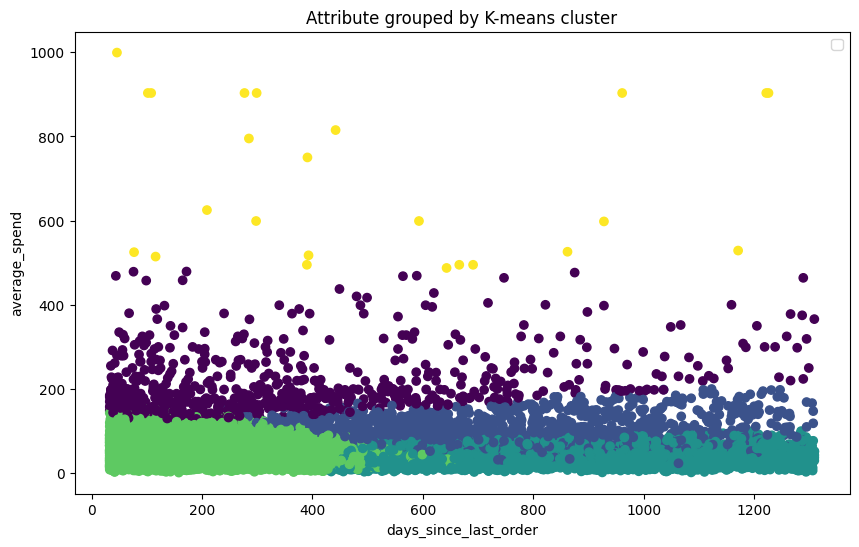

In [39]:
import matplotlib.pyplot as plt

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(predictions_df['days_since_last_order'], predictions_df['average_spend'], c=predictions_df["CENTROID_ID"], cmap='viridis')

plt.title('Attribute grouped by K-means cluster')
plt.xlabel('days_since_last_order')
plt.ylabel('average_spend')
plt.legend()
plt.show()

## **Summarize each cluster generated from the K-means model**

In [43]:
%%bigquery
SELECT centroid_id, feature, ROUND(numerical_value, 2) as value
FROM ML.CENTROIDS(MODEL `ecommerce.customer_segmentation_model`)

Query is running:   0%|          |

Downloading:   0%|          |

,centroid_id,feature,value
0,1,days_since_last_order,361.01
1,1,count_orders,1.46
2,1,average_spend,216.77
3,2,days_since_last_order,753.44
4,2,count_orders,2.28
5,2,average_spend,101.50
6,3,days_since_last_order,846.47
7,3,count_orders,1.38
8,3,average_spend,36.30
9,4,days_since_last_order,219.02


In [44]:
query = """
SELECT
 CONCAT('cluster ', CAST(centroid_id as STRING)) as centroid,
 average_spend,
 count_orders,
 days_since_last_order
FROM (
 SELECT centroid_id, feature, ROUND(numerical_value, 2) as value
 FROM ML.CENTROIDS(MODEL `{0}.{1}`)
)
PIVOT (
 SUM(value)
 FOR feature IN ('average_spend',  'count_orders', 'days_since_last_order')
)
ORDER BY centroid_id
""".format(dataset_name, model_name)

df_centroid = client.query(query).to_dataframe()
df_centroid.head()

,centroid,average_spend,count_orders,days_since_last_order
0,cluster 1,216.77,1.46,361.01
1,cluster 2,101.50,2.28,753.44
2,cluster 3,36.30,1.38,846.47
3,cluster 4,49.54,2.46,219.02
4,cluster 5,750.65,1.06,461.96


In [45]:
df_query = client.query(query).to_dataframe()
df_query.to_string(header=False, index=False)

cluster_info = []
for i, row in df_query.iterrows():
 cluster_info.append("{0}, average spend ${2}, count of orders per person {1}, days since last order {3}"
  .format(row["centroid"], row["count_orders"], row["average_spend"], row["days_since_last_order"]) )

cluster_info = (str.join("\n", cluster_info))
print(cluster_info)

cluster 1, average spend $216.77, count of orders per person 1.46, days since last order 361.01
cluster 2, average spend $101.5, count of orders per person 2.28, days since last order 753.44
cluster 3, average spend $36.3, count of orders per person 1.38, days since last order 846.47
cluster 4, average spend $49.54, count of orders per person 2.46, days since last order 219.02
cluster 5, average spend $750.65, count of orders per person 1.06, days since last order 461.96


### **Generating the marketing campaign using the Gemini model**

In [58]:
import pandas as pd
import vertexai
from vertexai.generative_models import GenerativeModel

vertexai.init(project=project_id, location=location)

# Create a Gemini model instance, using a more recent and available model
model = GenerativeModel("gemini-2.0-flash")

prompt = f"""
  You're a creative brand strategist, given the following clusters, come up with \
  creative brand persona, a catchy title, and next marketing action, \
  explained step by step. Identify the cluster number, the title of the person, a persona for them and the next marketing step.

  Clusters:
  {cluster_info}

  For each Cluster:
  * Title:
  * Persona:
  * Next marketing step:
"""

print(prompt)

response = model.generate_content(
   prompt,
   generation_config={
      "temperature": 0.1,
   }
)

print(response.text)


  You're a creative brand strategist, given the following clusters, come up with   creative brand persona, a catchy title, and next marketing action,   explained step by step. Identify the cluster number, the title of the person, a persona for them and the next marketing step.

  Clusters:
  cluster 1, average spend $216.77, count of orders per person 1.46, days since last order 361.01
cluster 2, average spend $101.5, count of orders per person 2.28, days since last order 753.44
cluster 3, average spend $36.3, count of orders per person 1.38, days since last order 846.47
cluster 4, average spend $49.54, count of orders per person 2.46, days since last order 219.02
cluster 5, average spend $750.65, count of orders per person 1.06, days since last order 461.96

  For each Cluster:
  * Title:
  * Persona:
  * Next marketing step:

Okay, here's a breakdown of each cluster, with a creative title, persona, and next marketing action, designed to re-engage and/or nurture each group:

**Cluste

# README

## Workshop: Data Analysis with BigQuery and Gemini

### Overview

This notebook provides a comprehensive walkthrough of a data analysis and machine learning project focused on customer segmentation. It demonstrates how to leverage Google Cloud's powerful tools—BigQuery for large-scale data processing, BigQuery ML (via BigFrames) for clustering, and the Gemini Pro model for creative content generation—to derive actionable business insights from raw e-commerce data.

The primary goal is to segment customers based on their purchasing behavior (Recency, Frequency, Monetary Value) and then use these segments to create targeted marketing campaigns.

### Technologies & Libraries Used

*   **Google Cloud:**
    *   Vertex AI
    *   BigQuery
    *   Colab Enterprise
*   **Python Libraries:**
    *   `google-cloud-bigquery`
    *   `google-cloud-aiplatform`
    *   `bigframes` (for interacting with BigQuery data using a pandas-like API)
    *   `pandas`
    *   `matplotlib` (for data visualization)
    *   `vertexai` (for using the Gemini model)

### Workflow

1.  **Data Preparation in BigQuery:**
    *   A SQL query is executed to process the `bigquery-public-data.thelook_ecommerce.order_items` public dataset.
    *   A new table, `ecommerce.customer_stats`, is created. This table aggregates customer data to calculate RFM (Recency, Frequency, Monetary) metrics: `days_since_last_order`, `count_orders`, and `average_spend`.

2.  **Data Exploration with BigFrames:**
    *   The `customer_stats` table from BigQuery is loaded into a BigQuery DataFrame (`bqdf`).
    *   Standard exploratory data analysis is performed using familiar pandas methods like `.head()`, `.info()`, and `.describe()` to understand the data's structure and statistics.

3.  **Customer Segmentation with K-Means:**
    *   The data is split into training and test sets.
    *   A K-Means clustering model with 5 clusters is created and trained on the RFM features using `bigframes.ml.cluster.KMeans`.
    *   The trained model is saved directly back into BigQuery for persistence and future use.
    *   Predictions are made on the test data to assign each customer to a specific cluster.

4.  **Visualization and Analysis:**
    *   The clusters are visualized using a `matplotlib` scatter plot to show the relationship between `days_since_last_order` and `average_spend`, colored by cluster.
    *   The centroids of the K-Means model are queried from BigQuery using `ML.CENTROIDS` to analyze the defining characteristics of each customer segment.

5.  **Generative AI for Marketing Strategy:**
    *   The Vertex AI SDK is initialized to use the Gemini Pro model.
    *   A detailed prompt is engineered, providing the model with the summarized data for each cluster.
    *   The model is asked to act as a creative brand strategist and generate a unique persona, a catchy campaign title, and a step-by-step marketing action plan for each of the 5 customer segments.